# 05 — Customer Segment Sales Distribution
Sales and profit comparison across Consumer, Corporate, and Home Office segments.


In [1]:
from pyhive import hive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("muted")

def get_conn():
    return hive.connect(host="hive-server2", port=10000,
                        database="default", auth="NONE")

def fetch_df(cur, sql):
    cur.execute(sql)
    cols = [d[0].split(".")[-1] for d in cur.description]
    return pd.DataFrame(cur.fetchall(), columns=cols)

def fmt_usd(v):
    if abs(v) >= 1_000_000:
        return f"${v/1_000_000:.2f}M"
    if abs(v) >= 1_000:
        return f"${v/1_000:.1f}K"
    return f"${v:.0f}"

conn = get_conn()
cur  = conn.cursor()
print("Connected.")


Connected.


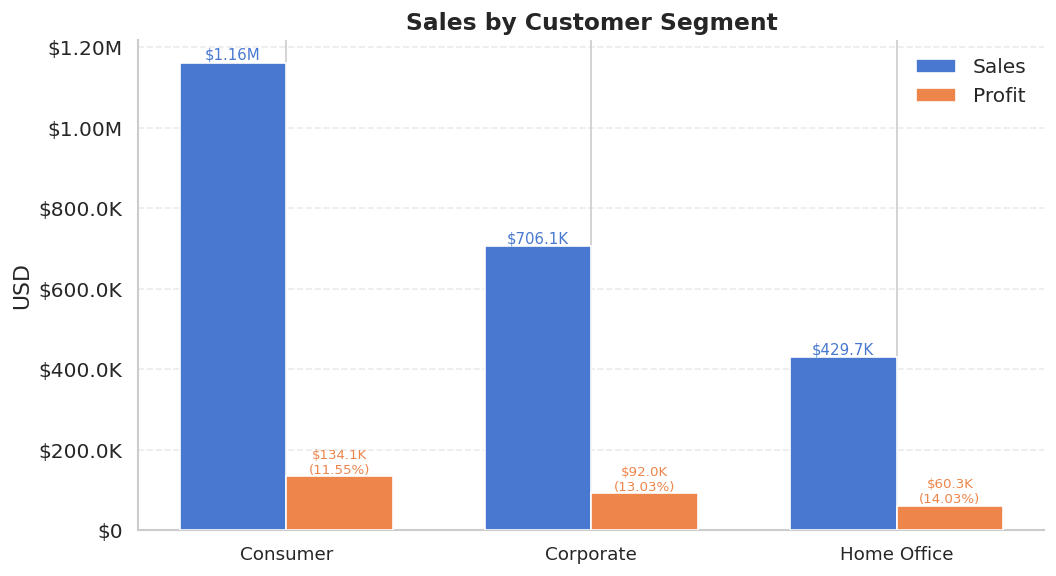

In [2]:
# ── Sales & Profit by Customer Segment ───────────────────────────────────────
seg = fetch_df(cur, """
    SELECT c.segment,
           COUNT(DISTINCT o.order_id)                    AS orders,
           ROUND(SUM(oi.sales),  2)                      AS sales,
           ROUND(SUM(oi.profit), 2)                      AS profit,
           ROUND(SUM(oi.profit)/SUM(oi.sales)*100, 2)   AS margin_pct
    FROM customers c
    JOIN orders      o  ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id    = oi.order_id
    GROUP BY c.segment
    ORDER BY sales DESC
""")

seg_colors = [PALETTE[0], PALETTE[1], PALETTE[2]]
bar_w      = 0.35
x          = range(len(seg))

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar([i - bar_w/2 for i in x], seg["sales"],
            bar_w, color=PALETTE[0], label="Sales",  edgecolor="white", zorder=3)
b2 = ax.bar([i + bar_w/2 for i in x], seg["profit"],
            bar_w, color=PALETTE[1], label="Profit", edgecolor="white", zorder=3)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1000,
            fmt_usd(bar.get_height()),
            ha="center", va="bottom", fontsize=9, color=PALETTE[0])
for bar, mg in zip(b2, seg["margin_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f"{fmt_usd(bar.get_height())}\n({mg}%)",
            ha="center", va="bottom", fontsize=8, color=PALETTE[1])

ax.set_xticks(list(x))
ax.set_xticklabels(seg["segment"], fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_usd(v)))
ax.legend(frameon=False)
ax.set_title("Sales by Customer Segment")
ax.set_ylabel("USD")
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()


In [3]:
cur.close()
conn.close()
print("Done.")


Done.
